# Topic 2: Time-Series forecasting [20 minutes]
Given our performance so far, we would like to predict our sales volume for the upcoming
months and use it to steer our business. The question3 dataset.csv contains our daily sales
volume for the last six years. You are asked to apply time series analysis to produce the
forecast volume for September of 2021 and share your results in 1 slide along with the
associated analysis methodology.
Topic 3: Entering a new ma

In [31]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose
from pmdarima import auto_arima
from statsmodels.tsa.statespace.sarimax import SARIMAX
import warnings
warnings.filterwarnings("ignore")


In [32]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

In [33]:
# Load the dataset

In [34]:
data = pd.read_csv('question3_dataset.csv')


In [35]:
# Explore the data 

In [36]:
data.head()

,date,volume
0,2016-01-01,1341
1,2016-01-02,2179
2,2016-01-03,4393
3,2016-01-04,3302
4,2016-01-05,2995


In [37]:
data.describe()

,volume
count,2070.000000
mean,2184.965217
std,960.960169
min,529.000000
25%,1519.250000
50%,1980.500000
75%,2635.750000
max,8801.000000


In [38]:
# Convert 'date' column to datetime and set as index

In [39]:
data['date'] = pd.to_datetime(data['date'])
data.set_index('date', inplace=True)

In [40]:
#infer the frequency of the data
data = data.asfreq(pd.infer_freq(data.index))

In [41]:
# Check the spacing between dates to confirm

In [42]:
print("\nPreview of time gaps:")
print(data.index.to_series().diff().value_counts().head())


Preview of time gaps:
date
1 days    2069
Name: count, dtype: int64


In [43]:
# 2) Seasonal decomposition (yearly seasonality for daily data)

In [44]:

result = seasonal_decompose(data['volume'], model='additive', period=365)

In [45]:
# 3) Trend plot

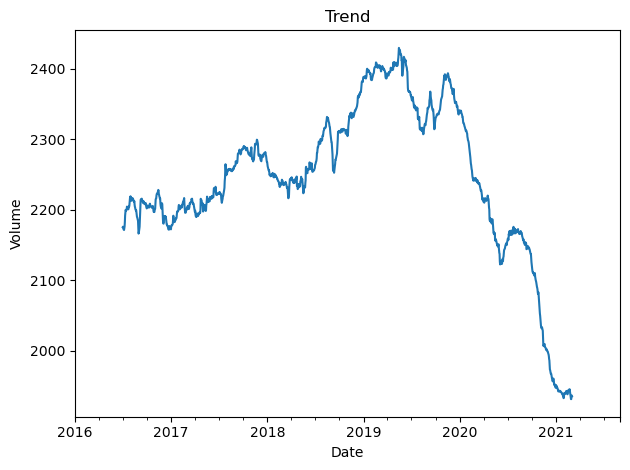

In [46]:

plt.figure()
result.trend.plot()
plt.title("Trend")
plt.xlabel("Date")
plt.ylabel("Volume")
plt.tight_layout()
plt.show()


In [47]:
# 4) Seasonal plot

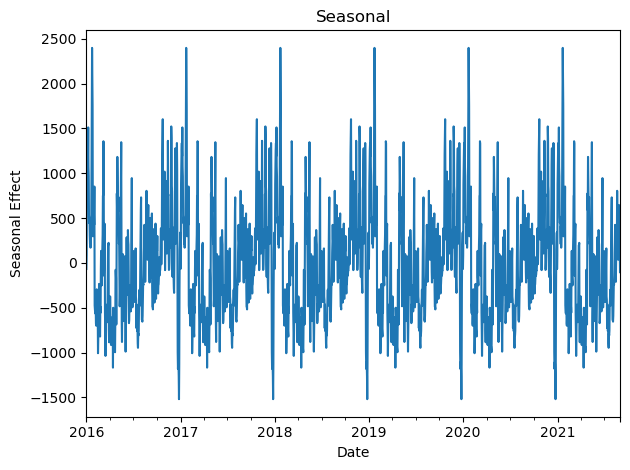

In [48]:

plt.figure()
result.seasonal.plot()
plt.title("Seasonal")
plt.xlabel("Date")
plt.ylabel("Seasonal Effect")
plt.tight_layout()
plt.show()

In [49]:
# 5) Residual plot

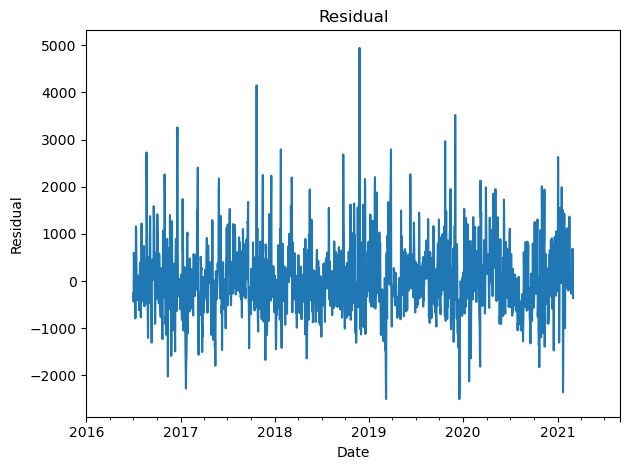

In [50]:

plt.figure()
result.resid.plot()
plt.title("Residual")
plt.xlabel("Date")
plt.ylabel("Residual")
plt.tight_layout()
plt.show()


# Seasonal decomposition result

#A clear yearly seasonal pattern, with volume peaking and dropping around the same months each year.
#A long-term trend, where volumes fluctuate but follow a general pattern over time.
#Noticeable seasonal cycles that repeat annually.

Because of this strong seasonal component, a SARIMA model (Seasonal ARIMA) is better suited than a standard ARIMA model. SARIMA can capture both the overall trend and the recurring yearly seasonality in the data, leading to more accurate forecasts for September 2021.


# SARIMA model(Seasonal Autoregressive Integrated Moving Average)


# Aggregate daily data to monthly sums:
1. Monthly Forecast Requirement:The task specifically asks for a sales volume forecast for September 2021, 
which implies a monthly prediction. Aggregating daily data to monthly sums aligns the analysis with this goal,
as forecasting at the monthly level is more relevant for strategic business decisions like inventory planning or budgeting.
2. Reduced Noise: Daily data often contains more noise and short-term fluctuations (e.g., day-to-day variations due to weekends or holidays).
Monthly aggregation smooths these fluctuations, making trends and seasonality clearer and more stable for modeling. 
# Clarity in Identifying Seasonality:
1.  Seasonal Periodicity: The decomposition aims to identify seasonal patterns, such as yearly cycles (e.g., higher sales in November/December)
Monthly data with a seasonal period of 12 (one year) is more straightforward for capturing such patterns compared to daily data, which might
require a longer seasonal period (e.g., 365 days for yearly seasonality or 7 days for weekly patterns). 
A 365-day period in daily data is computationally intensive and harder to interpret visually in decomposition.
2. Visual Interpretability: Decomposition plots (trend, seasonal, residual) are easier to interpret with monthly data 
because the seasonal component is more compact (12 points per year vs. 365). T
This makes it simpler to confirm the presence of yearly seasonality  
# 3. Computational Efficiency
1. Data Volume: The dataset spans six years (~2191 days from January 1, 2016, to August 31, 2021). 
Performing decomposition on daily data with thousands of points is computationally heavier and may obscure patterns due to high-frequency
noise. Monthly data reduces this to ~68 points, making the analysis faster and more manageable.
2. Model Fitting: SARIMA modelling on daily data with a long seasonal period (e.g., 365) is computationally expensive and prone to overfitting,
especially with auto_arima. Monthly aggregation simplifies parameter estimation while maintaining predictive power for the target horizon.
# Decision-Making Timeframe: 
1. Business decisions (e.g., inventory, staffing, marketing) for September 2021 are typically made at a monthly 
level, not daily.
2. Smoother Patterns: Daily data might show erratic spikes (e.g., a single high-sales day due to a promotion). 
Monthly sums average out such anomalies, providing a more reliable basis for strategic planning.
    
    

In [51]:

monthly_data = data['volume'].resample('M').sum()


In [52]:
# Visualize the monthly time series

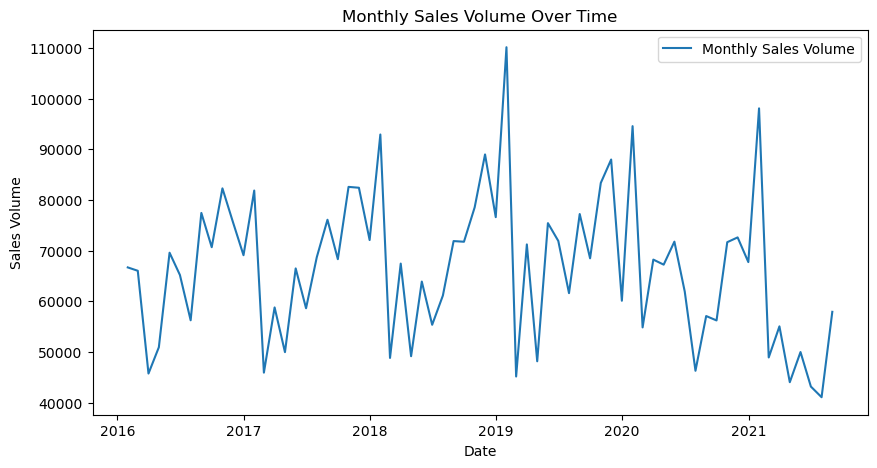

<Figure size 640x480 with 0 Axes>

In [53]:
fig = plt.figure(figsize=(10, 5))
plt.plot(monthly_data, label='Monthly Sales Volume')
plt.title('Monthly Sales Volume Over Time')
plt.xlabel('Date')
plt.ylabel('Sales Volume')
plt.legend()
plt.show()

plt.savefig("my_plot.png", dpi=300, bbox_inches='tight')

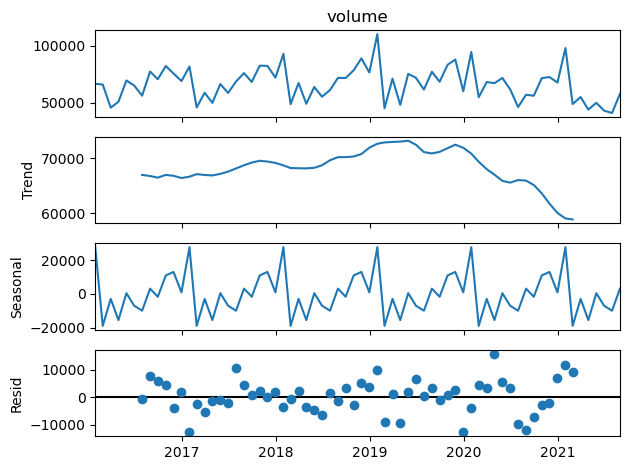

In [54]:
decomposition = seasonal_decompose(monthly_data, model='additive', period=12)
decomposition.plot()
plt.show()


In [55]:
# Plot Autocorrelation (ACF)
# The gradual decline in the ACF means the data is not stationary and it has a trend.

<Figure size 1000x500 with 0 Axes>

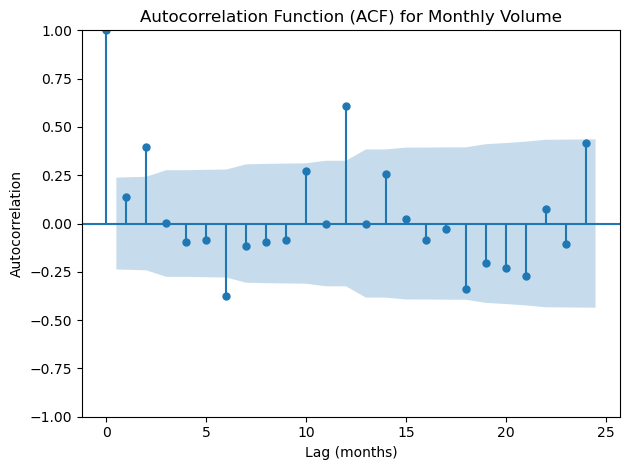

In [56]:
plt.figure(figsize=(10, 5))
plot_acf(monthly_data, lags=24)  # 24 lags = 2 years of monthly data
plt.title('Autocorrelation Function (ACF) for Monthly Volume')
plt.xlabel('Lag (months)')
plt.ylabel('Autocorrelation')
plt.tight_layout()
plt.show()


In [57]:
# Plot Partial Autocorrelation (PACF)
# The PACF has a strong spike at lag 1 and smaller ones near lag 12, suggesting short-term autoregressive behavior or 
#seasonal AR(1) component with a 12-month period.


<Figure size 1000x500 with 0 Axes>

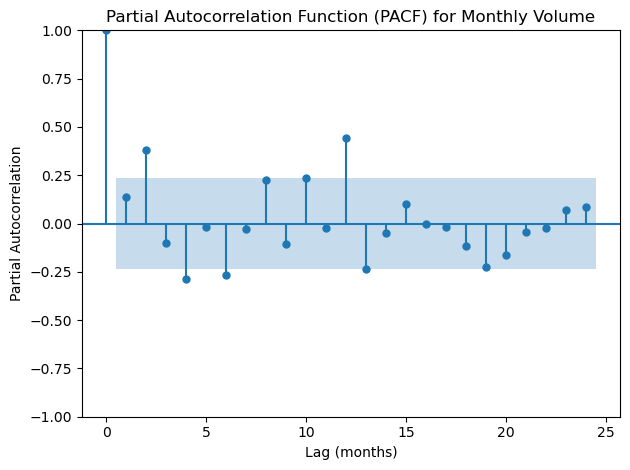

In [58]:
plt.figure(figsize=(10, 5))
plot_pacf(monthly_data, lags=24, method='ywm')  # Yule-Walker Modified for stability
plt.title('Partial Autocorrelation Function (PACF) for Monthly Volume')
plt.xlabel('Lag (months)')
plt.ylabel('Partial Autocorrelation')
plt.tight_layout()
plt.show()

In [59]:
# Check stationarity with Augmented Dickey-Fuller test
# p-value = 0.98, the series is non-stationary and needs differencing


In [60]:
adf_result = adfuller(monthly_data)
print('ADF Statistic:', adf_result[0])
print('p-value:', adf_result[1])

ADF Statistic: 0.42637914416732614
p-value: 0.9824550704814564


In [61]:
# Use auto_arima to find optimal SARIMA parameters
# Instead of manually picking (p,d,q)(P,D,Q,m), it finds the best combination based on the lowest AIC (Akaike Information Criterion).

In [62]:
model = auto_arima(monthly_data, seasonal=True, m=12, 
                   start_p=0, start_q=0, max_p=3, max_q=3,
                   start_P=0, start_Q=0, max_P=2, max_Q=2,
                   d=1, D=1, trace=True, error_action='ignore', suppress_warnings=True)


Performing stepwise search to minimize aic
 ARIMA(0,1,0)(0,1,0)[12]             : AIC=1193.445, Time=0.03 sec
 ARIMA(1,1,0)(1,1,0)[12]             : AIC=1190.348, Time=0.04 sec
 ARIMA(0,1,1)(0,1,1)[12]             : AIC=1188.821, Time=0.07 sec
 ARIMA(0,1,1)(0,1,0)[12]             : AIC=1197.528, Time=0.01 sec
 ARIMA(0,1,1)(1,1,1)[12]             : AIC=inf, Time=0.29 sec
 ARIMA(0,1,1)(0,1,2)[12]             : AIC=1190.158, Time=0.11 sec
 ARIMA(0,1,1)(1,1,0)[12]             : AIC=1191.110, Time=0.04 sec
 ARIMA(0,1,1)(1,1,2)[12]             : AIC=inf, Time=0.59 sec
 ARIMA(0,1,0)(0,1,1)[12]             : AIC=1189.876, Time=0.02 sec
 ARIMA(1,1,1)(0,1,1)[12]             : AIC=1188.369, Time=0.09 sec
 ARIMA(1,1,1)(0,1,0)[12]             : AIC=1198.399, Time=0.05 sec
 ARIMA(1,1,1)(1,1,1)[12]             : AIC=1189.900, Time=0.16 sec
 ARIMA(1,1,1)(0,1,2)[12]             : AIC=1189.958, Time=0.22 sec
 ARIMA(1,1,1)(1,1,0)[12]             : AIC=1192.009, Time=0.07 sec
 ARIMA(1,1,1)(1,1,2)[12]     

In [63]:
print(model.summary())

                                      SARIMAX Results                                       
Dep. Variable:                                    y   No. Observations:                   68
Model:             SARIMAX(1, 1, 0)x(0, 1, [1], 12)   Log Likelihood                -590.739
Date:                              Thu, 16 Oct 2025   AIC                           1187.478
Time:                                      15:08:05   BIC                           1193.500
Sample:                                  01-31-2016   HQIC                          1189.807
                                       - 08-31-2021                                         
Covariance Type:                                opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.3135      0.072     -4.376      0.000      -0.454      -0.173
ma.S.L12      -0.43

In [64]:
# Fit the SARIMA model with the best parameters

In [75]:
sarima_model = SARIMAX(monthly_data, order=model.order, seasonal_order=model.seasonal_order)
sarima_fit = sarima_model.fit(disp=False)

In [66]:
# Forecast for September 2021 (next month after August 2021)

In [76]:
forecast_steps = 1  
forecast = sarima_fit.get_forecast(steps=forecast_steps)
forecast_mean = forecast.predicted_mean
forecast_ci = forecast.conf_int()

In [68]:
# Print the forecast

In [69]:
print(f"Forecasted Sales Volume for September 2021: {forecast_mean.iloc[0]:.0f}")
print(f"95% Confidence Interval: {forecast_ci.iloc[0].values}")


Forecasted Sales Volume for September 2021: 53196
95% Confidence Interval: [33846.36124827 72545.46500873]


In [70]:
# Plot the forecast with confidence intervals

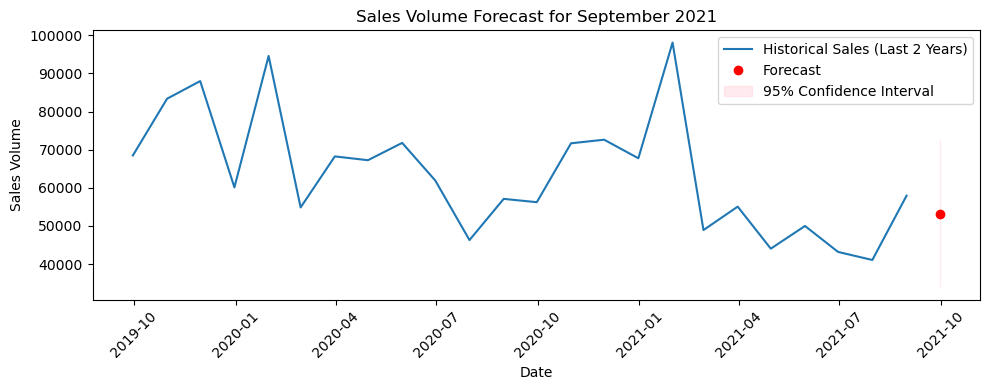

In [74]:
plt.figure(figsize=(10, 4))
plt.plot(monthly_data[-24:], label='Historical Sales (Last 2 Years)')
plt.plot(forecast_mean.index, forecast_mean, 'ro', label='Forecast')  # Use 'ro' for red dot
plt.fill_between(forecast_ci.index, forecast_ci.iloc[:, 0], forecast_ci.iloc[:, 1], 
                 color='pink', alpha=0.3, label='95% Confidence Interval')
plt.title('Sales Volume Forecast for September 2021')
plt.xlabel('Date')
plt.ylabel('Sales Volume')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("sales_forecast.png", dpi=300, bbox_inches='tight')
plt.show()

In [72]:
# Residual diagnostics to validate the model
# Residuals are randonly distributed

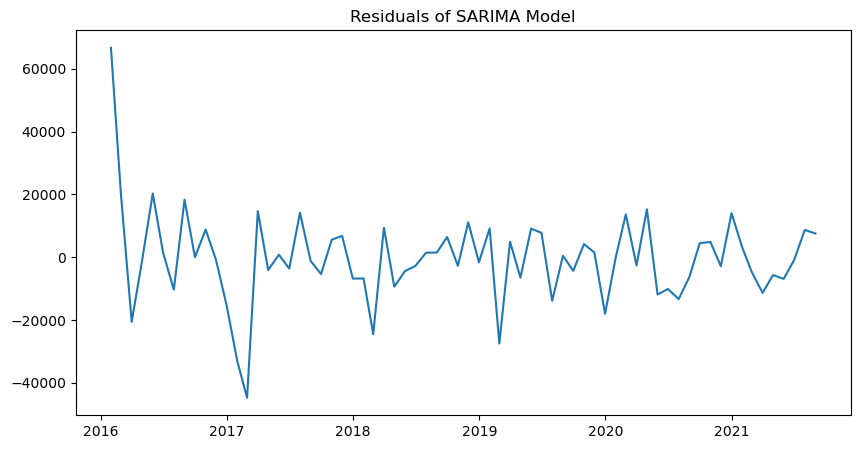

In [73]:
residuals = sarima_fit.resid
plt.figure(figsize=(10, 5))
plt.plot(residuals)
plt.title('Residuals of SARIMA Model')
plt.show()